In [28]:
import pandas as pd
url = "https://raw.githubusercontent.com/owid/covid-19-data/refs/heads/master/public/data/owid-covid-data.csv"
ds_covid19 = pd.read_csv(url)
ds_covid19

,iso_code,continent,location,date,total_cases,new_cases,new_cases_smoothed,total_deaths,new_deaths,new_deaths_smoothed,...,male_smokers,handwashing_facilities,hospital_beds_per_thousand,life_expectancy,human_development_index,population,excess_mortality_cumulative_absolute,excess_mortality_cumulative,excess_mortality,excess_mortality_cumulative_per_million
0,AFG,Asia,Afghanistan,2020-01-05,0.0,0.0,NaN,0.0,0.0,NaN,...,NaN,37.75,0.5,64.83,0.51,41128772,NaN,NaN,NaN,NaN
1,AFG,Asia,Afghanistan,2020-01-06,0.0,0.0,NaN,0.0,0.0,NaN,...,NaN,37.75,0.5,64.83,0.51,41128772,NaN,NaN,NaN,NaN
2,AFG,Asia,Afghanistan,2020-01-07,0.0,0.0,NaN,0.0,0.0,NaN,...,NaN,37.75,0.5,64.83,0.51,41128772,NaN,NaN,NaN,NaN
3,AFG,Asia,Afghanistan,2020-01-08,0.0,0.0,NaN,0.0,0.0,NaN,...,NaN,37.75,0.5,64.83,0.51,41128772,NaN,NaN,NaN,NaN
4,AFG,Asia,Afghanistan,2020-01-09,0.0,0.0,NaN,0.0,0.0,NaN,...,NaN,37.75,0.5,64.83,0.51,41128772,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
429430,ZWE,Africa,Zimbabwe,2024-07-31,266386.0,0.0,0.0,5740.0,0.0,0.0,...,30.7,36.79,1.7,61.49,0.57,16320539,NaN,NaN,NaN,NaN
429431,ZWE,Africa,Zimbabwe,2024-08-01,266386.0,0.0,0.0,5740.0,0.0,0.0,...,30.7,36.79,1.7,61.49,0.57,16320539,NaN,NaN,NaN,NaN
429432,ZWE,Africa,Zimbabwe,2024-08-02,266386.0,0.0,0.0,5740.0,0.0,0.0,...,30.7,36.79,1.7,61.49,0.57,16320539,NaN,NaN,NaN,NaN
429433,ZWE,Africa,Zimbabwe,2024-08-03,266386.0,0.0,0.0,5740.0,0.0,0.0,...,30.7,36.79,1.7,61.49,0.57,16320539,NaN,NaN,NaN,NaN


### 1. verificare le dimensioni del dataset e i relativi metadati

In [31]:
ds_covid19.shape

(429435, 67)

In [9]:
ds_covid19.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 429435 entries, 0 to 429434
Data columns (total 67 columns):
 #   Column                                      Non-Null Count   Dtype  
---  ------                                      --------------   -----  
 0   iso_code                                    429435 non-null  object 
 1   continent                                   402910 non-null  object 
 2   location                                    429435 non-null  object 
 3   date                                        429435 non-null  object 
 4   total_cases                                 411804 non-null  float64
 5   new_cases                                   410159 non-null  float64
 6   new_cases_smoothed                          408929 non-null  float64
 7   total_deaths                                411804 non-null  float64
 8   new_deaths                                  410608 non-null  float64
 9   new_deaths_smoothed                         409378 non-null  float64
 

### 2. Per ogni continente
### 2.1 Numero di casi fin dall'inizio della pandemia

In [108]:
# Si effetua un 'EDA - Explorazioni dei Dati "continet e location"
print(ds_covid19["continent"].unique())
print(ds_covid19[ds_covid19["continent"].isna()]["location"].unique())

['Asia' nan 'Europe' 'Africa' 'Oceania' 'North America' 'South America']
['Africa' 'Asia' 'Europe' 'European Union (27)' 'High-income countries'
 'Low-income countries' 'Lower-middle-income countries' 'North America'
 'Oceania' 'South America' 'Upper-middle-income countries' 'World']


In [109]:
# prendendo in considerazione la colonna "continent" della seconda parte del esercizio finale
ds_paesi = ds_covid19[ds_covid19["continent"].notna()]
    
# Si prende un campeone dil dataset, per cio si prende il ultimo valore disponibile per ogni paese
ultimo_valore = ds_paesi.sort_values("date").groupby("location").tail(1)

# Casi totali della pandemia dall'inizio della pandemia
continente = ultimo_valore.groupby("continent")["total_cases"].sum()
print(continente)

continent
Africa            13145380.0
Asia             251147941.0
Europe           219394045.0
North America    124492666.0
Oceania           12364304.0
South America     68809418.0
Name: total_cases, dtype: float64


In [ ]:
# prendedo in considerazio il filtro di continent

### 2.2 percentuale rispetto al totale mondiale

In [110]:
mondo = continente.sum()
continente = (continente /mondo) * 100
print(continente)

continent
Africa            1.906914
Asia             36.432374
Europe           31.826046
North America    18.059330
Oceania           1.793608
South America     9.981728
Name: total_cases, dtype: float64


### 3. Selezionare i dati relativi all'italia nell 2022, i nuovi casi vengono registrati settimanalmente, filtrare via giorni che hanno misurazioni e mostrare con grafici adeguiati 

In [111]:
# prima bisogna filtrare i dati relativi al 2022
italia2022 = ds_covid19[(ds_covid19["location"] == "Italy") & (ds_covid19["date"] >= "2022-01-01") & (ds_covid19["date"] <= "2022-12-31")]
italia2022

,iso_code,continent,location,date,total_cases,new_cases,new_cases_smoothed,total_deaths,new_deaths,new_deaths_smoothed,...,male_smokers,handwashing_facilities,hospital_beds_per_thousand,life_expectancy,human_development_index,population,excess_mortality_cumulative_absolute,excess_mortality_cumulative,excess_mortality,excess_mortality_cumulative_per_million
186002,ITA,Europe,Italy,2022-01-01,5622431.0,0.0,36797.00,136530.0,0.0,140.86,...,27.8,NaN,3.18,83.51,0.89,59037472,NaN,NaN,NaN,NaN
186003,ITA,Europe,Italy,2022-01-02,6267035.0,644604.0,92086.29,137513.0,983.0,140.43,...,27.8,NaN,3.18,83.51,0.89,59037472,168226.3,12.99,8.06,2849.48
186004,ITA,Europe,Italy,2022-01-03,6267035.0,0.0,92086.29,137513.0,0.0,140.43,...,27.8,NaN,3.18,83.51,0.89,59037472,NaN,NaN,NaN,NaN
186005,ITA,Europe,Italy,2022-01-04,6267035.0,0.0,92086.29,137513.0,0.0,140.43,...,27.8,NaN,3.18,83.51,0.89,59037472,NaN,NaN,NaN,NaN
186006,ITA,Europe,Italy,2022-01-05,6267035.0,0.0,92086.29,137513.0,0.0,140.43,...,27.8,NaN,3.18,83.51,0.89,59037472,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
186362,ITA,Europe,Italy,2022-12-27,25060503.0,0.0,18918.14,184168.0,0.0,114.00,...,27.8,NaN,3.18,83.51,0.89,59037472,NaN,NaN,NaN,NaN
186363,ITA,Europe,Italy,2022-12-28,25060503.0,0.0,18918.14,184168.0,0.0,114.00,...,27.8,NaN,3.18,83.51,0.89,59037472,NaN,NaN,NaN,NaN
186364,ITA,Europe,Italy,2022-12-29,25060503.0,0.0,18918.14,184168.0,0.0,114.00,...,27.8,NaN,3.18,83.51,0.89,59037472,NaN,NaN,NaN,NaN
186365,ITA,Europe,Italy,2022-12-30,25060503.0,0.0,18918.14,184168.0,0.0,114.00,...,27.8,NaN,3.18,83.51,0.89,59037472,NaN,NaN,NaN,NaN


In [123]:
# Adesso bisogno filtrare i nuovi casi che vengono registrati settimanalmente, doviamo prendere in considerazioni di filtrare anchi gli spazzi vuoti 
dati_puliti = italia2022[italia2022["new_cases"].notna() & (italia2022["new_cases"] != 0)]

### 3.1 l'Evoluzione del casi totali dall'inizio alla fine dell'anno

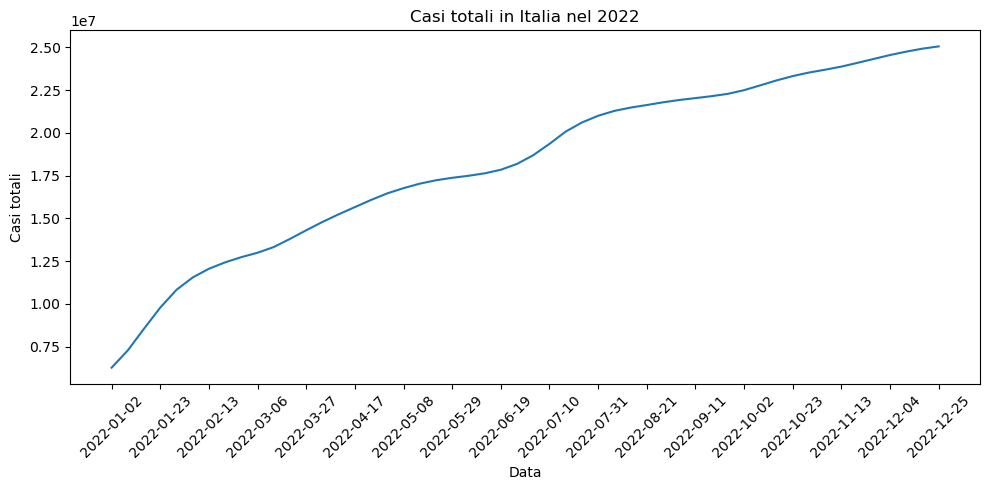

In [114]:
import matplotlib.pyplot as plt

plt.figure(figsize = (10,5))
plt.plot(dati_puliti["date"], dati_puliti["total_cases"])

# per non vedere tutte le date insime ho deciso di avvere un intervalo per fare il grafico piu ordinato
plt.xticks(dati_puliti["date"][::3], rotation = 45)
plt.title("Casi totali in Italia nel 2022")
plt.xlabel("Data")
plt.ylabel("Casi totali")
plt.tight_layout()
plt.show()

### 3.2 Numero di nuovi casi rispetto alla data 

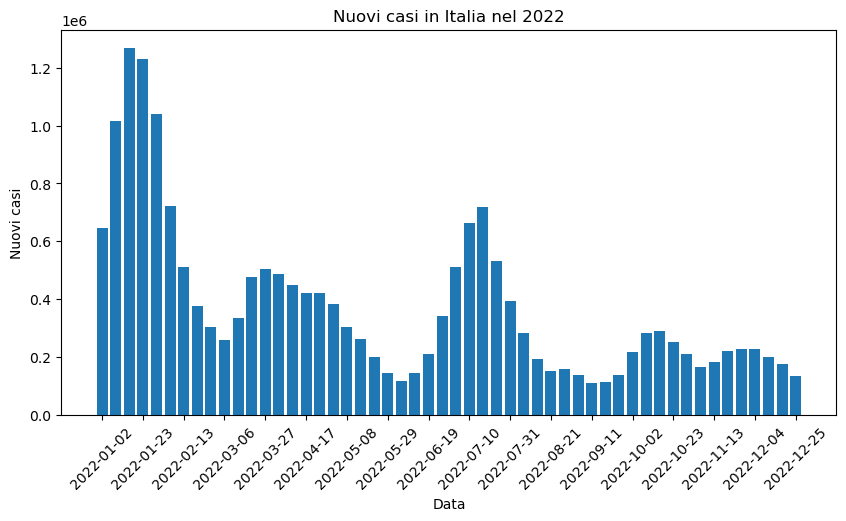

In [115]:
plt.figure(figsize = (10,5))
plt.bar(dati_puliti["date"], dati_puliti["new_cases"])

# anche in questo caso ho deciso di avvere un intervalo di dati per fare piu ordinato la visulizzazione del grafico 
plt.xticks(dati_puliti["date"][::3], rotation = 45)
plt.title("Nuovi casi in Italia nel 2022")
plt.xlabel("Data")
plt.ylabel("Nuovi casi")
plt.show()

### 4. Dati di Italia, Germana e Francia

### 4.1 Boxplot della diferenza tra le nazioni riguardo al numero di pazienti in terapia intensiva tra maggio 2022 e aprile 2023

In [122]:
paesi1 = ["Italy","Germany","France"]

# Per primo paso si debe filtrare la informazione prendendo come riferimento il periodo di ricerca
periodo = ds_covid19[(ds_covid19["location"].isin(paesi1)) & (ds_covid19["date"] >= "2022-05-01") & (ds_covid19["date"] <= "2023-04-30")]

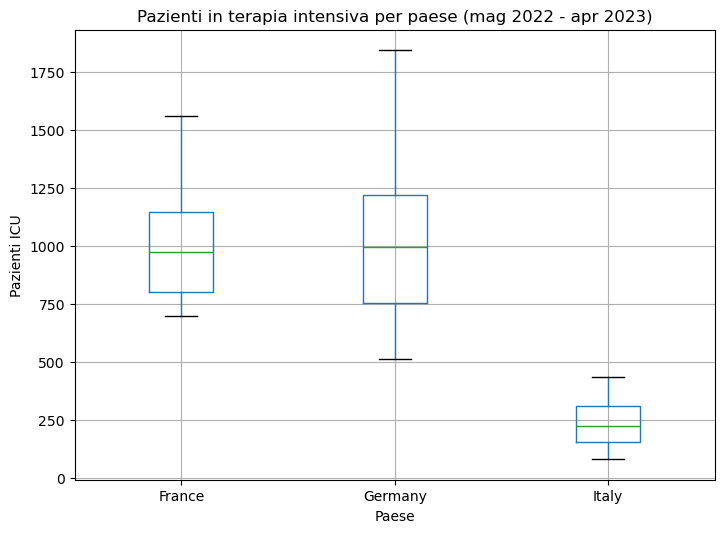

In [117]:
# per il boxplot si prende in considerazione la colonna icu_pacients
periodo.boxplot(column = "icu_patients", by = "location", figsize = (8,6)) # ho presso in considerazione usare 8 pollici di largezza e 6 di altezza per fare il boxplot piu leggibile

plt.title("Pazienti in terapia intensiva per paese (mag 2022 - apr 2023)")
plt.suptitle("")  # ho preso in considerazione per rimuove il titolo automatico che aggiunge pandas
plt.xlabel("Paese")
plt.ylabel("Pazienti ICU")
plt.show()

### 4.2 Comento delle conclusioni del boxpolt

In [89]:
# Prendeno in considerazione che gli altri  paesi (Francia e Germania) hanno una 
# popolazione  diverse tra loro con l'Italia si possono usare come strumenti di comparazione per 
# verificare il impacto della pandermia nel periodo di maggio dal 2022 a aprile 2023,
# grazie a questa comparativa possiamo capire che la maggiore quantita di pazienti in 
# terapia intensiva si trova in Germania e Francia con un intervalo di 750 a 1250 persone, 
# mentre l'Italia si distingue per i valori più bassi trovandosi in un intervalo di 150 a 450 persone aprossimativamente.
# Grazie alla quantita piu bassa di popolazione che ah l'Italia con gli altri paesi possimao 
# dire in ipotesi che la quantita di pazienti in ICU e minore dovuto alla popolazione che possiede l'Italia  
# e anche per le differenze nei criteri di ricovero tra i sistemi sanitari nazionali, 
# per fare valido questa ipotesi potrebbe servire aggiungere piu informazione per confermare la autenticita.


### 5. Dati di Italia, Germana, Francia e Spagna nel 2021

### 5.1 Somma dei pazienti ospedaizzati per paese

In [118]:
paesi2= ["Italy", "Germany", "France", "Spain"]

# Per primo paso si debe filtrare la informazione prendendo come riferimento il anno di ricerca
Dati2021 = ds_covid19[(ds_covid19["location"].isin(paesi2)) & (ds_covid19["date"] >= "2021-01-01") & (ds_covid19["date"] <= "2021-12-31")]

In [121]:
# Visualizzazione numerica
somma = Dati2021.groupby("location")["hosp_patients"].sum()
print(somma)

location
France     6008717.0
Germany          0.0
Italy      4419950.0
Spain      2411706.0
Name: hosp_patients, dtype: float64


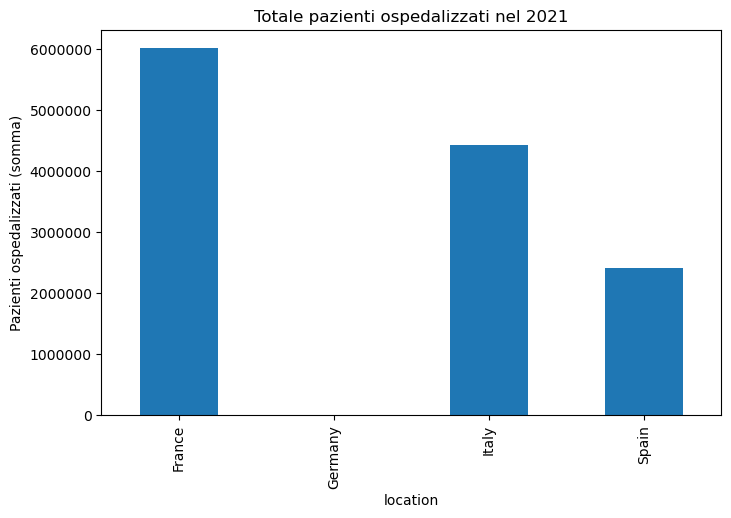

In [132]:
# Visualizzazione grafica
somma.plot(kind = "bar", figsize = (8,5))
plt.title("Totale pazienti ospedalizzati nel 2021")
plt.ylabel("Pazienti ospedalizzati (somma)")
plt.ticklabel_format(style="plain", axis="y") # ho usato questa funsione per disativare la notazione scientifica per avere un grafico piu pulito
plt.show()

In [128]:
# possimao vedere che nella manera graffica e numerica la Germania a dati nulli
# per cio si fara la una verifica dei dati per confermare si eh veridico ho se 
# ce un problema con il codice 

In [130]:
germania2021 = Dati2021[Dati2021["location"] == "Germany"]

# Quante righe totali ci sono nel 2021 in Germania?
print("Righe totali:", len(germania2021))

# Quanti valori sono nulli in hosp_patients?
print("Valori nulli:", germania2021["hosp_patients"].isna().sum())

Righe totali: 365
Valori nulli: 365


In [134]:
# visto che la Germania a dei dati nulli si controlla se anche gli altri paesi hanno dati nulli
for paese3 in paesi2:
    nulli = Dati2021[Dati2021["location"] == paese3]["hosp_patients"].isna().sum()
    totale_righe = len(Dati2021[Dati2021["location"] == paese3])
    print(f"{paese3}: {nulli} valori nulli su {totale_righe} righe totali")

Italy: 0 valori nulli su 365 righe totali
Germany: 365 valori nulli su 365 righe totali
France: 0 valori nulli su 365 righe totali
Spain: 0 valori nulli su 365 righe totali


### 5.2 Comentario

In [ ]:
# Analizzando i dati sui pazienti ospedalizzati nel 2021, solo la Germania presenta valori
# nulli per l'intero anno. Francia, Italia e Spagna non hanno invece nessun valore 
# mancante. Invece la Germania manca completamente il dato per tutto il periodo 
# osservato, non è possibile ne opportuno sostituire i valori mancanti, visto che non 
# esiste alcun dato reale su cui basare una stima. È più corretto segnalare esplicitamente 
#che questa metrica non è disponibile per la Germania in questo dataset, invece 
# di generare numeri fittizi che potrebbero fuorviare l'analisi.